## Car Price Prediction with Machine Learning

**Objective**

The objective of this project is to build a machine learning model that predicts car prices based on various features such as car brand, mileage, horsepower, fuel type, and other specifications. The project involves data preprocessing, exploratory data analysis, model training, and performance evaluation.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
plt.style.use("ggplot")

In [33]:
df=pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [34]:
df.shape

(301, 9)

In [35]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [37]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


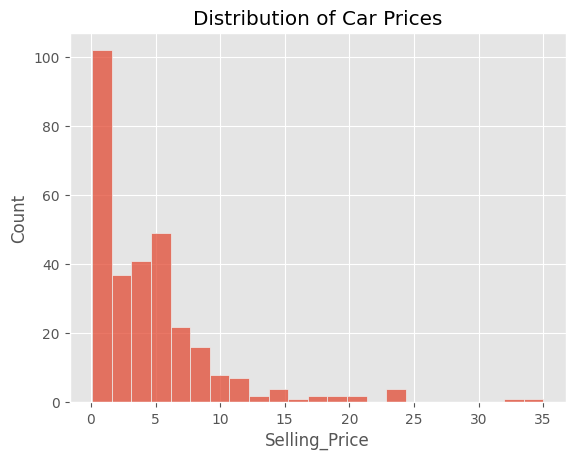

In [38]:
sns.histplot(df["Selling_Price"])
plt.title("Distribution of Car Prices")
plt.show()

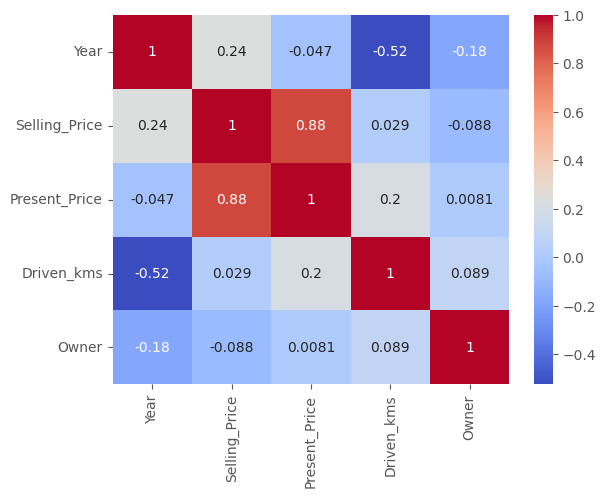

In [39]:
numeric=df.select_dtypes(include="number")
sns.heatmap(numeric.corr(),annot=True,cmap="coolwarm")
plt.show()

In [40]:
cat_cols=df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"{col}")
    print(f"{df[col].unique()}\n")

Car_Name
['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS Sport ' 'Honda Dream Yuga '
 'Bajaj Avenger Street 220' 'He

In [41]:
df.drop("Car_Name",axis=1,inplace=True)

In [42]:
le=LabelEncoder()
df["Fuel_Type"]=le.fit_transform(df["Fuel_Type"])
df["Selling_type"]=le.fit_transform(df["Selling_type"])
df["Transmission"]=le.fit_transform(df["Transmission"])

In [43]:
X=df.drop("Selling_Price",axis=1)
y=df["Selling_Price"]

In [44]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Linear Regression

In [45]:
lin=LinearRegression()
lin.fit(X_train,y_train)

LinearRegression()

In [46]:
y_pred_lin=lin.predict(X_test)

In [47]:
print("MAE: ",mean_absolute_error(y_test,y_pred_lin))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred_lin)))
print("r2_score: ",r2_score(y_test,y_pred_lin))

MAE:  1.2219323621755538
RMSE:  1.8792498207982187
r2_score:  0.8466902419663176


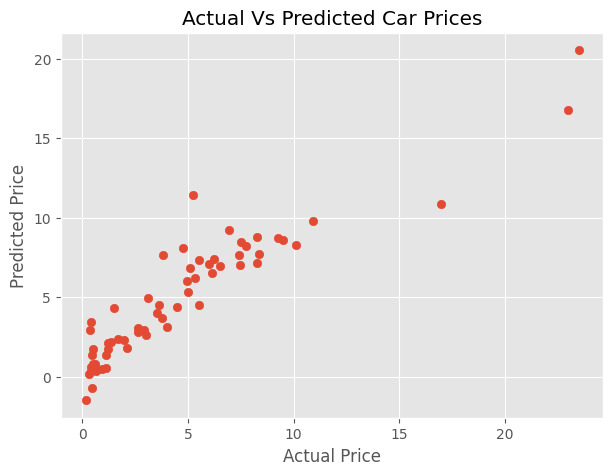

In [48]:
plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred_lin)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Vs Predicted Car Prices")
plt.show()

In [49]:
lin_coef=pd.DataFrame({
    "Feature":X.columns,"Coefficient":lin.coef_
})
lin_coef.sort_values("Coefficient",ascending=False)

,Feature,Coefficient
1,Present_Price,0.439871
0,Year,0.362731
2,Driven_kms,-0.000005
6,Owner,-0.921467
4,Selling_type,-1.169683
3,Fuel_Type,-1.324534
5,Transmission,-1.637471


### Ridge

In [50]:
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [51]:
rid=Ridge(alpha=1.0)
rid.fit(X_train_scaled,y_train)

Ridge()

In [52]:
y_pred_rid=rid.predict(X_test_scaled)

In [53]:
print("MAE: ",mean_absolute_error(y_test,y_pred_rid))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred_rid)))
print("r2_score: ",r2_score(y_test,y_pred_rid))

MAE:  1.2230053256230877
RMSE:  1.8823936871522708
r2_score:  0.8461768577953986


In [54]:
ridge_coef=pd.DataFrame({
    "Feature":X.columns,"Coefficient":rid.coef_
})
ridge_coef.sort_values("Coefficient",ascending=False)
ridge_coef

,Feature,Coefficient
0,Year,1.038528
1,Present_Price,3.921283
2,Driven_kms,-0.229207
3,Fuel_Type,-0.566416
4,Selling_type,-0.568956
5,Transmission,-0.546621
6,Owner,-0.246732


### Lasso

In [55]:
ls=Lasso(alpha=0.1)
ls.fit(X_train_scaled,y_train)

Lasso(alpha=0.1)

In [56]:
y_pred_ls=ls.predict(X_test_scaled)

In [57]:
print("MAE: ",mean_absolute_error(y_test,y_pred_ls))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred_ls)))
print("r2_score: ",r2_score(y_test,y_pred_ls))

MAE:  1.2314942627003191
RMSE:  1.9156064234626067
r2_score:  0.84070089619914


In [58]:
lasso_coef=pd.DataFrame({
    "Feature":X.columns,"Coefficient":ls.coef_
})
lasso_coef.sort_values("Coefficient",ascending=False)
lasso_coef

,Feature,Coefficient
0,Year,1.028072
1,Present_Price,3.915487
2,Driven_kms,-0.104447
3,Fuel_Type,-0.486212
4,Selling_type,-0.510815
5,Transmission,-0.434427
6,Owner,-0.164732


### Comparision Table

In [59]:
results=pd.DataFrame({
    "Model":["Linear Regression","Ridge","Lasso"],
    "R2 Score":[r2_score(y_test,y_pred_lin),
               r2_score(y_test,y_pred_rid),
               r2_score(y_test,y_pred_ls)]
})
results

,Model,R2 Score
0,Linear Regression,0.846690
1,Ridge,0.846177
2,Lasso,0.840701


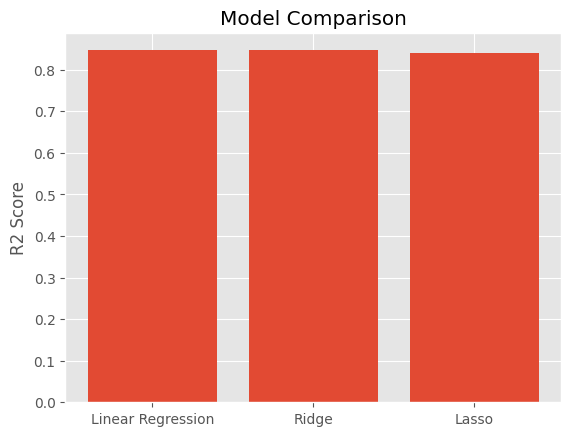

In [60]:
plt.bar(results["Model"], results["R2 Score"])
plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()

**Insights**

- Present Price showed the strongest positive relationship with Selling Price, indicating that cars with higher current market value tend to have higher resale prices.
- Vehicle characteristics such as Year, Fuel Type, Transmission, and Kilometers Driven significantly influence the selling price of a car.
- The correlation analysis revealed that some features have a stronger impact on car prices than others, helping identify the most important - predictors.
- Among the three models tested, Linear Regression achieved the highest R² score (0.8467), slightly outperforming Ridge (0.8462) and Lasso (0.8407).
- The similar performance of Linear Regression, Ridge, and Lasso suggests that the dataset does not suffer from severe overfitting and the model predictions are stable.
- The Actual vs Predicted Price plot showed that most predicted values were close to the actual values, indicating good predictive performance.

**Conclusion**

This project successfully developed a machine learning model to predict car selling prices using vehicle and market-related features. After preprocessing, encoding categorical variables, and training multiple regression models, Linear Regression achieved the best performance with an R² score of approximately 0.85. The results demonstrate that machine learning can effectively estimate car prices and support data-driven pricing decisions in the used car market.